### ML Lab-5
#### Name: Yashmi Patle
#### Section:A
#### Batch:A1
#### Roll No:15

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_predict,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv("Diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


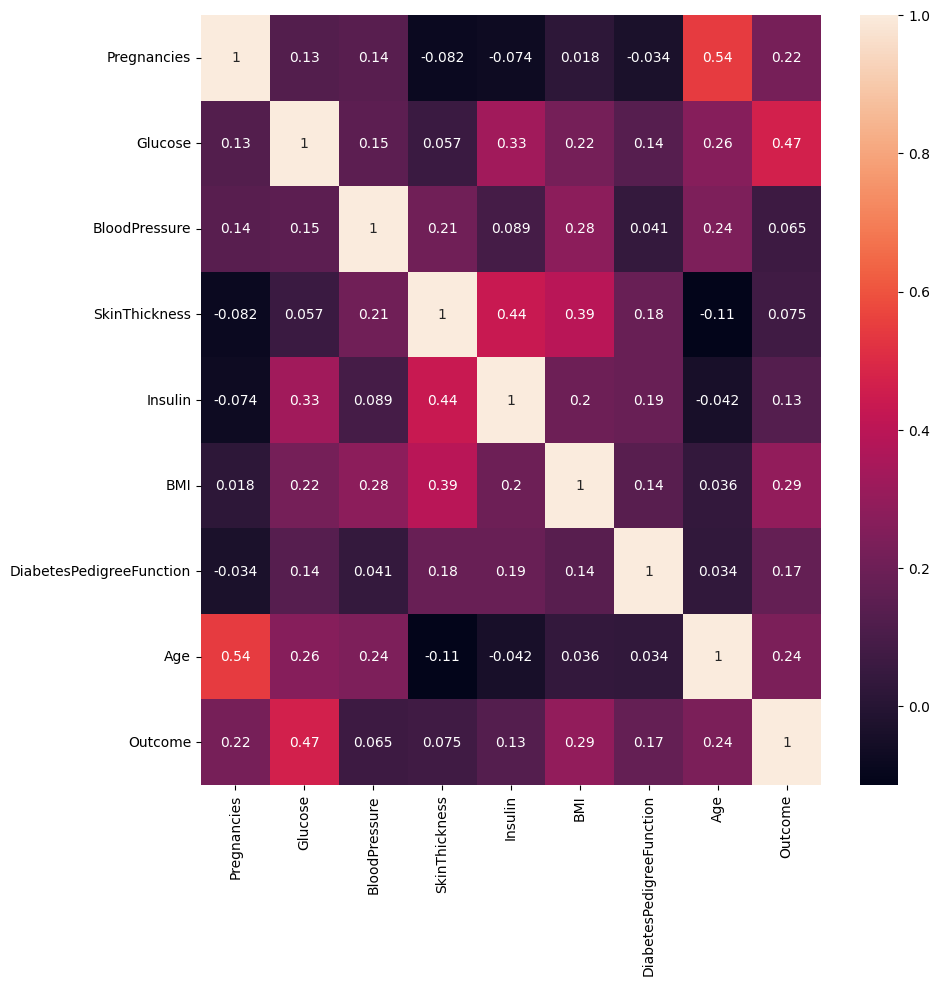

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

<Figure size 1000x1000 with 0 Axes>

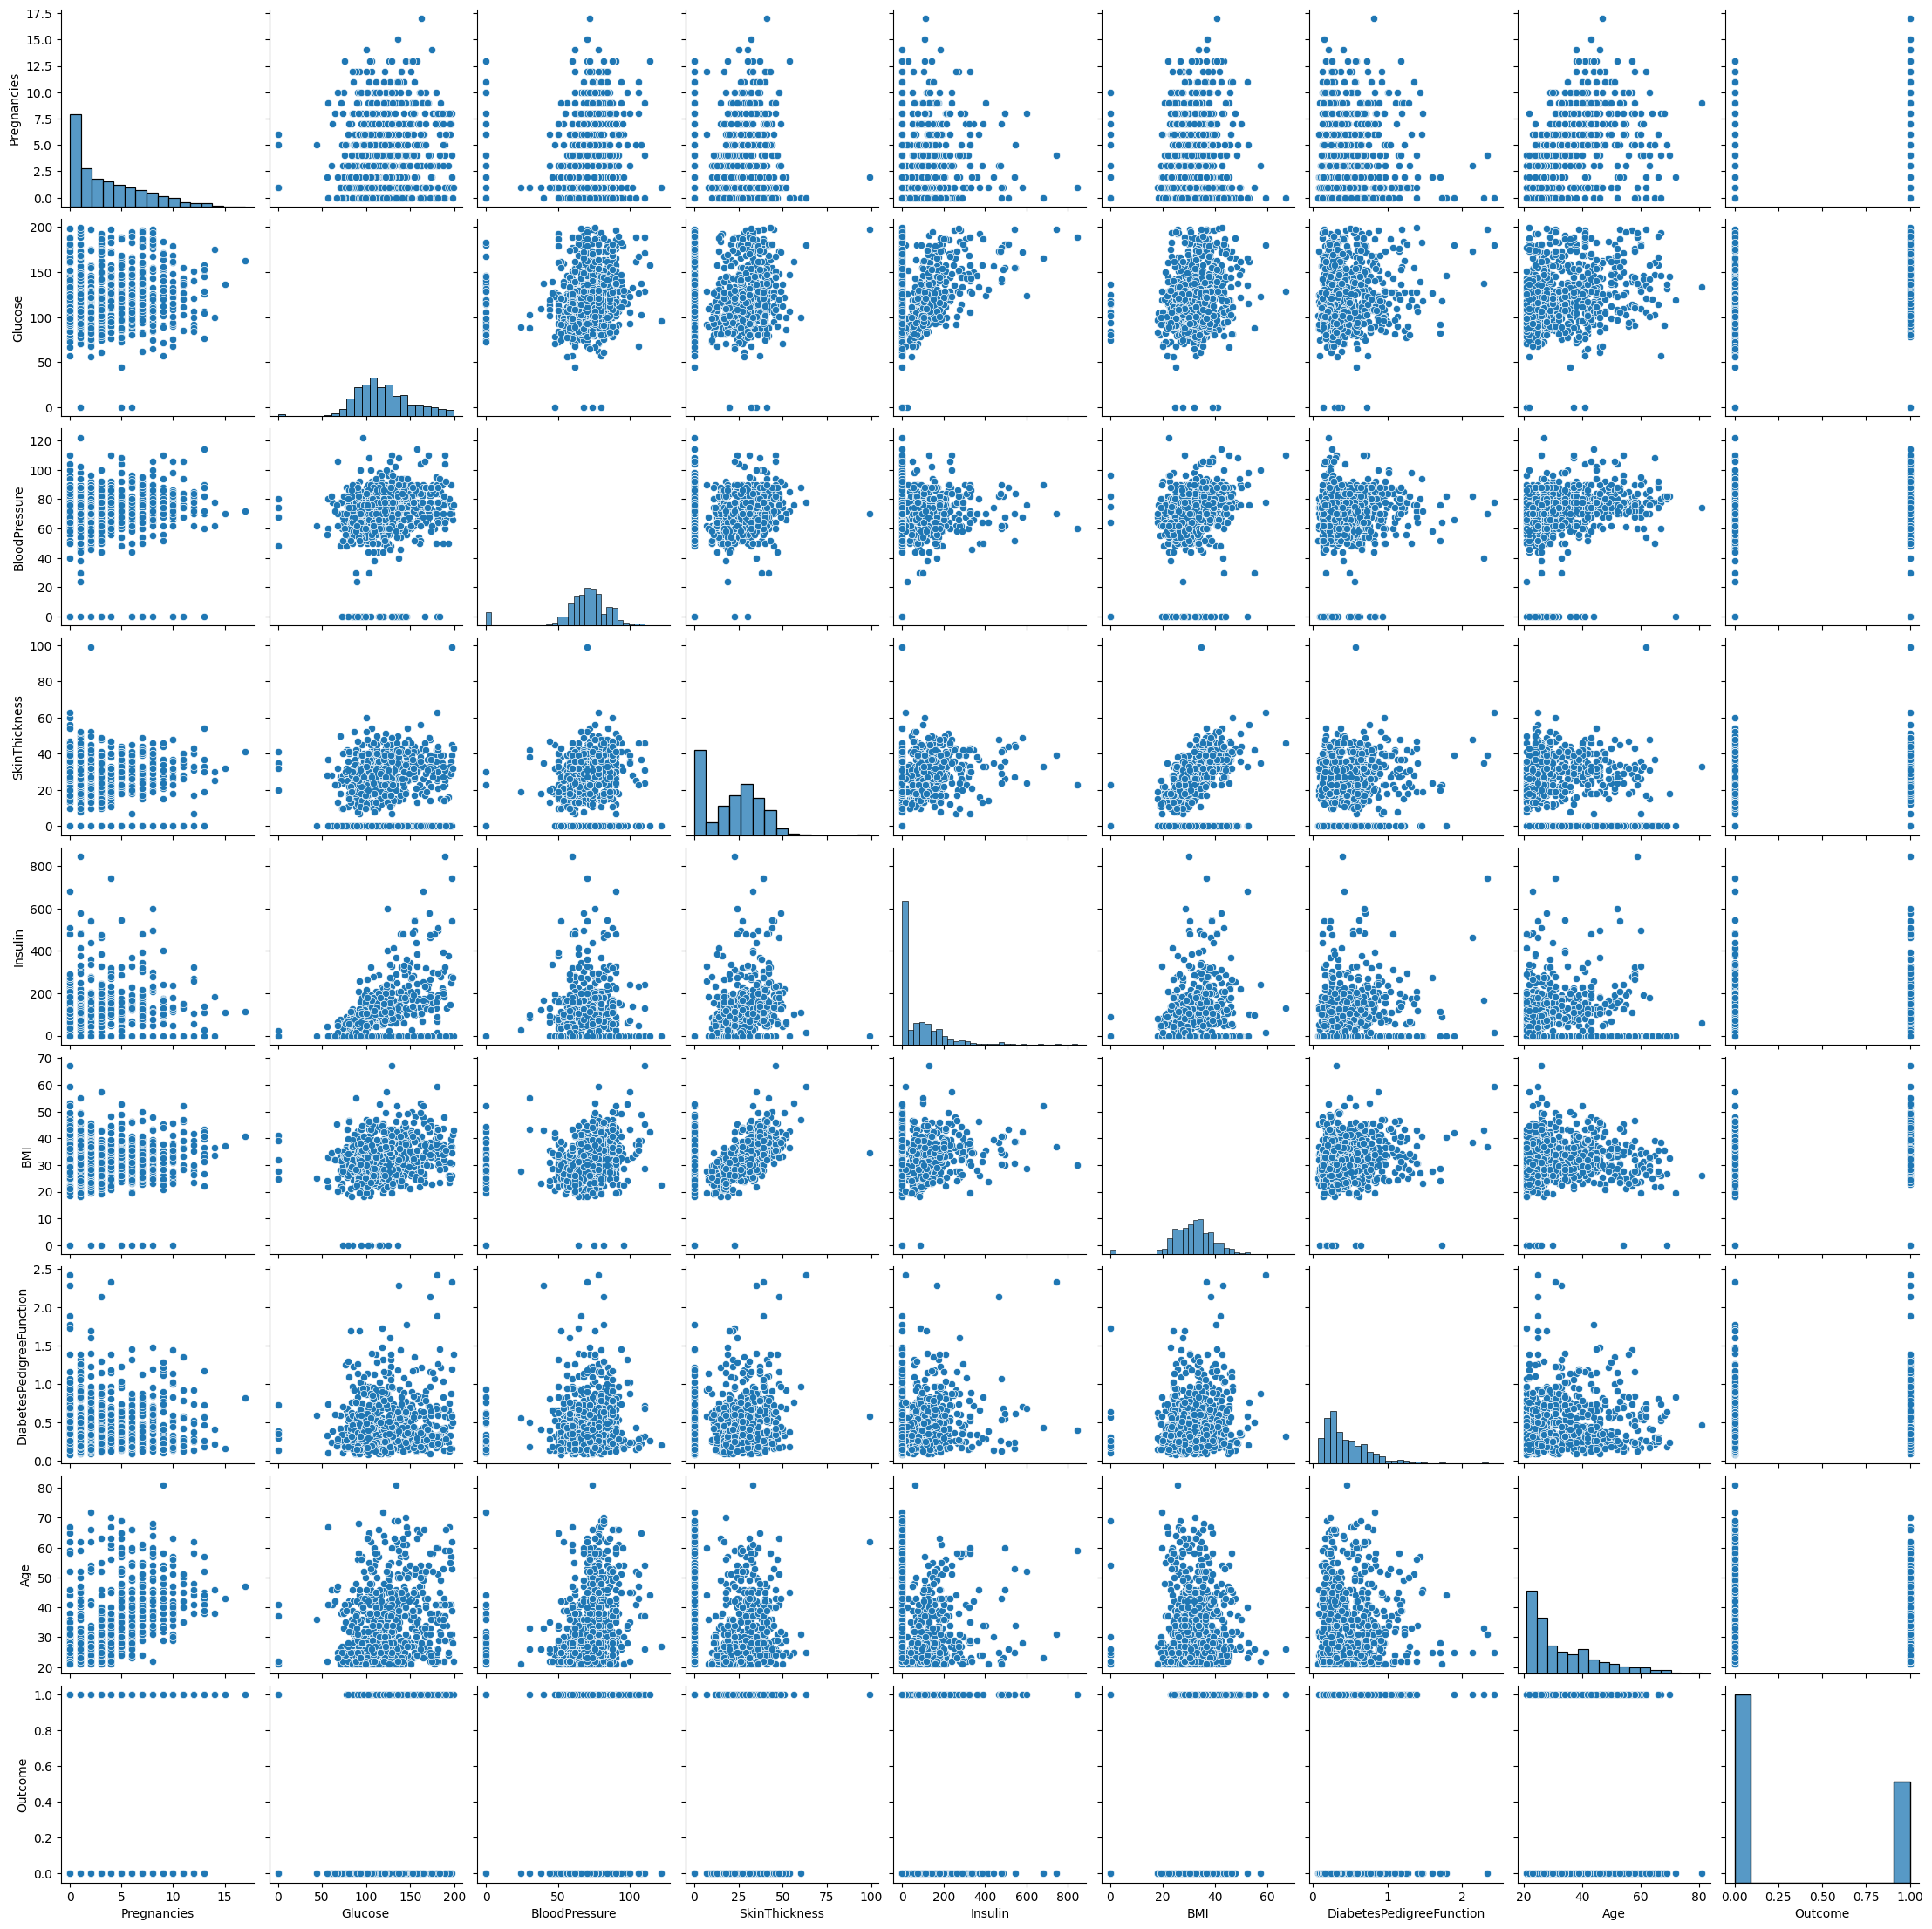

In [ ]:
plt.figure(figsize=(10,10))
sns.pairplot(df)
plt.show()

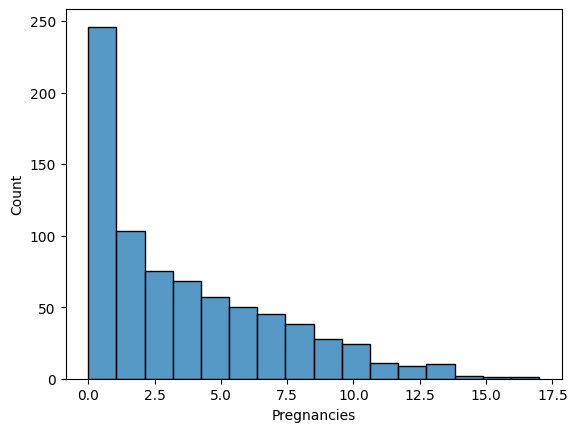

In [ ]:
sns.histplot(df['Pregnancies'])
plt.show()

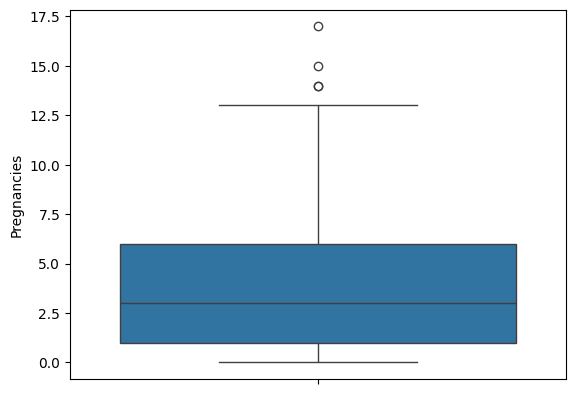

In [ ]:
sns.boxplot(df['Pregnancies'])
plt.show()

In [ ]:
zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts=(df[zero_columns]==0).sum()
print("Zero Values in Each Column:")
print(zero_counts)

Zero Values in Each Column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
df_clean=df.copy()
df_clean[zero_columns]=df_clean[zero_columns].replace(0,np.nan)
print("Missing Value after replacing invalid zeros:")
print(df_clean.isnull().sum())

Missing Value after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
for col in zero_columns:
  df_clean[col]=df_clean[col].fillna(df_clean[col].median())
print("Missing Value after median imputation:")
print(df_clean.isnull().sum())

Missing Value after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


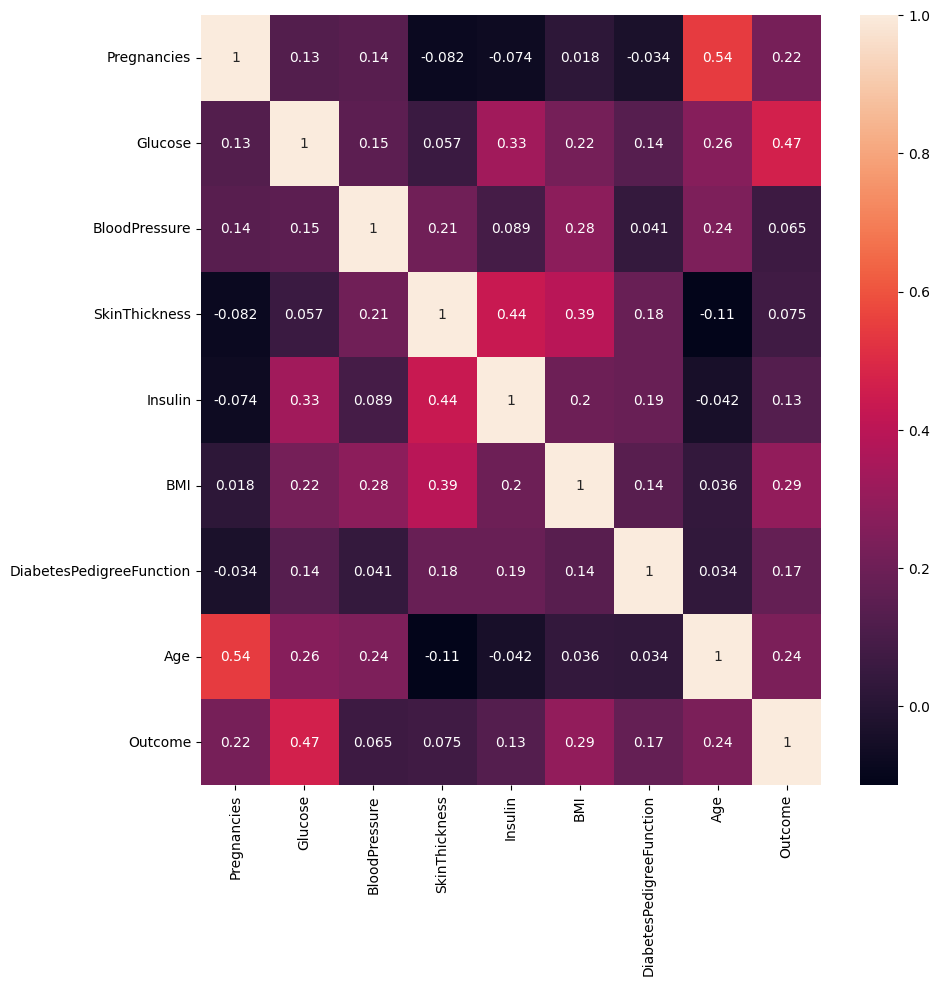

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
X=df_clean.drop("Outcome",axis=1)
y=df_clean["Outcome"]
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (768, 8)
Shape of y: (768,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training samples: ",X_train.shape[0])
print("Testing samples: ",X_test.shape[0])

Training samples:  614
Testing samples:  154


In [ ]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))
print("Testing distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Testing distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [ ]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [ ]:
comparison=pd.DataFrame({
    "Original Mean": X_train.mean(),
    "Original Std": X_train.std(),
    "Scaled Mean": X_train_scaled.mean(axis=0),
    "Scaled Std": X_train_scaled.std(axis=0)
})
display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [ ]:
K=5

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(X_test_scaled)
print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [ ]:
y_prob =knn.predict_proba(X_test_scaled)
print("Probabilities:")
print(y_prob[:20])

Probabilities:
[[0.4 0.6]
 [0.8 0.2]
 [0.8 0.2]
 [0.4 0.6]
 [1.  0. ]
 [0.8 0.2]
 [0.8 0.2]
 [0.2 0.8]
 [1.  0. ]
 [0.4 0.6]
 [0.6 0.4]
 [0.4 0.6]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.4 0.6]
 [0.2 0.8]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")


Accuracy:0.7532


In [ ]:
precision=precision_score(y_test,y_pred)
print(f"Precision:{precision:.4f}")

Precision:0.6600


In [ ]:
recall=recall_score(y_test,y_pred)
print(f"Recall:{recall:.4f}")

Recall:0.6111


In [ ]:
f1=f1_score(y_test,y_pred)
print(f"F1 Score:{f1:.4f}")

F1 Score:0.6346


In [ ]:
print(classification_report(y_test,y_pred,target_names=["No Diabetes","Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[83 17]
 [21 33]]


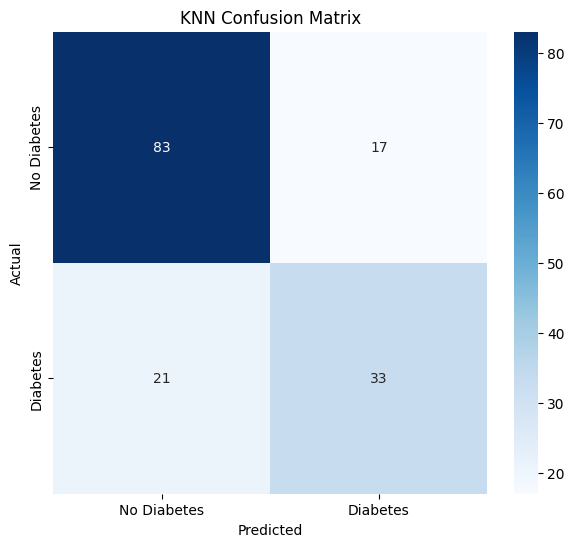

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
k_values=range(1,31)
train_accuracy=[]
test_accuracy=[]
for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_scaled,y_train)
  train_accuracy.append(model.score(X_train_scaled,y_train))
  test_accuracy.append(model.score(X_test_scaled,y_test))

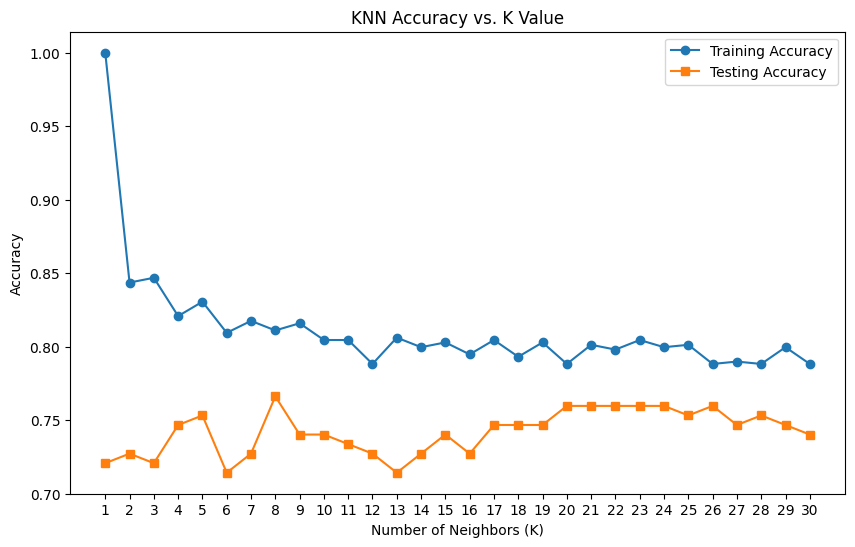

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker="o",label="Training Accuracy")
plt.plot(k_values,test_accuracy,marker="s",label="Testing Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. K Value")
plt.xticks(k_values)
plt.legend()
plt.show()

In [ ]:
best_k_accuracy=k_values[np.argmax(test_accuracy)]
best_accuracy=max(test_accuracy)
print("Best k:",best_k_accuracy)
print("Best Test Accuracy:",best_accuracy)

Best k: 8
Best Test Accuracy: 0.7662337662337663


In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=[]
for k in range(1,31):
  model=KNeighborsClassifier(n_neighbors=k)
  scores=cross_val_score(model,X_train_scaled,y_train,cv=cv,scoring="accuracy")
  cv_scores.append(scores.mean())

In [ ]:
best_k_cv=np.argmax(cv_scores)+1
print("Best k based on cross Validation: ",best_k_cv)
print("Best CV accuracy:",max(cv_scores))

Best k based on cross Validation:  13
Best CV accuracy: 0.7703718512594963


In [ ]:
param_grid={"n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],
"metric":["euclidean","manhattan","minkowski"],
"p":[1,2]
}

In [ ]:
grid_search=GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("Grid Search completed")

Grid Search completed


In [ ]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}


In [ ]:
print("Best CV accuracy:")
print(grid_search.best_score_)

Best CV accuracy:
0.7769025723044115


In [ ]:
best_knn=grid_search.best_estimator_
print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)


In [ ]:
final_pred=best_knn.predict(X_test_scaled)
final_prob=best_knn.predict_proba(X_test_scaled)[:,1]